In [1]:
import tensorflow as tf
import numpy as np
import os
import zipfile
import cv2  
import matplotlib.pyplot as plt 
import gc 
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB0, InceptionV3, Xception
from tensorflow.keras.applications.xception import preprocess_input as inception_preprocess
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

In [2]:
zip_path = "archive.zip"
extract_to = "dataset" 

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Dataset extracted successfully.")
print("Extracted folders:")
print(os.listdir("dataset"))
train_dir = tf.keras.utils.image_dataset_from_directory(
    "dataset/training",
    image_size=(224, 224),
    batch_size=32
)

test_dir = tf.keras.utils.image_dataset_from_directory(
    "dataset/testing",
    image_size=(224, 224),
    batch_size=32
)
print("Training classes:", train_dir.class_names)

print("Testing classes:", test_dir.class_names)



Dataset extracted successfully.
Extracted folders:
['Testing', 'Training']
Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.
Training classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
def crop_img_vis(img, padding=10):
    

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    
    if not contours:
       
        return img, [img, img, img, img]

    c = max(contours, key=cv2.contourArea)
    

    step1_img = img.copy()
    step2_img = img.copy()
    cv2.drawContours(step2_img, [c], -1, (0, 255, 255), 3)

    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])
    
    step3_img = step2_img.copy()
    cv2.circle(step3_img, extLeft, 8, (0, 0, 255), -1)
    cv2.circle(step3_img, extRight, 8, (0, 255, 0), -1)
    cv2.circle(step3_img, extTop, 8, (255, 0, 0), -1)
    cv2.circle(step3_img, extBot, 8, (255, 255, 0), -1)

  
    h, w, _ = img.shape
    x1 = max(0, extLeft[0] - padding)
    y1 = max(0, extTop[1] - padding)
    x2 = min(w, extRight[0] + padding)
    y2 = min(h, extBot[1] + padding)
    
    final_crop = img[y1:y2, x1:x2]
    
   
    if final_crop.size == 0:
        return img, [img, img, img, img]

    return final_crop, [step1_img, step2_img, step3_img, final_crop]

In [4]:
IMG_SIZE = (224, 224)
def load_data_from_dir(data_dir, class_names):
    images, labels_list = [], []
    label_map = {name: i for i, name in enumerate(class_names)}
    print(f"Loading data from: {data_dir}")

    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path): continue
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            image = cv2.imread(img_path)
            if image is None: continue
            
            # Preprocessing without exception handling
            cropped_bgr, _ = crop_img_vis(image)
            if cropped_bgr.size == 0: cropped_bgr = image
            gray_image = cv2.cvtColor(cropped_bgr, cv2.COLOR_BGR2GRAY)
            image = cv2.bilateralFilter(gray_image, 2, 50, 50)
            final_image_bgr = cv2.applyColorMap(gray_image, cv2.COLORMAP_BONE)
            resized_image_bgr = cv2.resize(final_image_bgr, IMG_SIZE)
            images.append(resized_image_bgr)
            labels_list.append(label_map[class_name])

    return np.array(images), np.array(labels_list)

In [5]:
train_dir = "dataset/training"
test_dir = "dataset/testing"
class_names = sorted(os.listdir(train_dir))
print(f"Found classes: {class_names}")

Found classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:
xtrain, ytrain = load_data_from_dir(train_dir, class_names)
X_temp, y_temp = load_data_from_dir(test_dir, class_names)
xval, X_test, yval, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)



Loading data from: dataset/training
Loading data from: dataset/testing


In [7]:
print(f"\nTraining set size: {len(xtrain)}")
print(f"Validation set size: {len(xval)}")
print(f"Test set size: {len(X_test)}")


Training set size: 5712
Validation set size: 655
Test set size: 656


In [8]:
xtrain = inception_preprocess(xtrain)
xtest =  inception_preprocess(X_test)
ytrain = to_categorical(ytrain, num_classes=4)
ytest = to_categorical(y_test, num_classes=4)

In [9]:
xval = inception_preprocess(xval)
yval = to_categorical(yval, num_classes=4)

In [10]:
print("xtrain shape:", xtrain.shape)
print("xval shape:", xval.shape)
print("xtest shape:", xtest.shape)
print("ytrain shape:", ytrain.shape)
print("yval shape:", yval.shape)
print("ytest shape:", ytest.shape)


xtrain shape: (5712, 224, 224, 3)
xval shape: (655, 224, 224, 3)
xtest shape: (656, 224, 224, 3)
ytrain shape: (5712, 4)
yval shape: (655, 4)
ytest shape: (656, 4)


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

train_generator = datagen.flow(
    xtrain,
    ytrain,
    batch_size=32
)


In [12]:
from tensorflow.keras.applications import InceptionV3

base_model = InceptionV3(
    include_top=False,
    input_shape=(224, 224, 3),
    weights='imagenet'
)

base_model.trainable = False


for layer in base_model.layers[-30:]:
    layer.trainable = True


In [13]:
\
\'/x= layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(250,activation='relu')(x)
x=layers.Dropout(0.4)(x)
x = layers.Dense(100,activation='relu')(x)
x= layers.Dropout(0.4)(x)
x = layers.Dense(25,activation='relu')(x)
predict= layers.Dense(4,activation='softmax')(x)
model=models.Model(inputs=base_model.input,outputs=predict)


In [14]:
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])
x = model.fit( train_generator,batch_size=32,validation_data=(xval, yval), epochs=25, verbose=1, shuffle=True)


Epoch 1/25
179/179 [==============================] - 151s 688ms/step - loss: 0.8479 - accuracy: 0.6565 - val_loss: 0.4293 - val_accuracy: 0.8519
Epoch 2/25
179/179 [==============================] - 118s 661ms/step - loss: 0.4063 - accuracy: 0.8570 - val_loss: 0.3300 - val_accuracy: 0.8855
Epoch 3/25
179/179 [==============================] - 120s 668ms/step - loss: 0.2923 - accuracy: 0.9041 - val_loss: 0.2399 - val_accuracy: 0.9191
Epoch 4/25
179/179 [==============================] - 124s 693ms/step - loss: 0.2301 - accuracy: 0.9205 - val_loss: 0.1994 - val_accuracy: 0.9359
Epoch 5/25
179/179 [==============================] - 117s 651ms/step - loss: 0.1707 - accuracy: 0.9422 - val_loss: 0.1668 - val_accuracy: 0.9420
Epoch 6/25
179/179 [==============================] - 116s 648ms/step - loss: 0.1481 - accuracy: 0.9512 - val_loss: 0.1367 - val_accuracy: 0.9420
Epoch 7/25
179/179 [==============================] - 114s 635ms/step - loss: 0.1169 - accuracy: 0.9636 - val_loss: 0.1302 -

In [15]:
loss, accuracy = model.evaluate(xtest, ytest, verbose=0)
print(f"Loss: {loss:.6f}")
print(f"Accuracy: {accuracy:.6f}")


Loss: 0.040250
Accuracy: 0.989329


In [17]:
ypred=np.argmax(model.predict(xtest),axis=1)

21/21 [==============================] - 2s 69ms/step


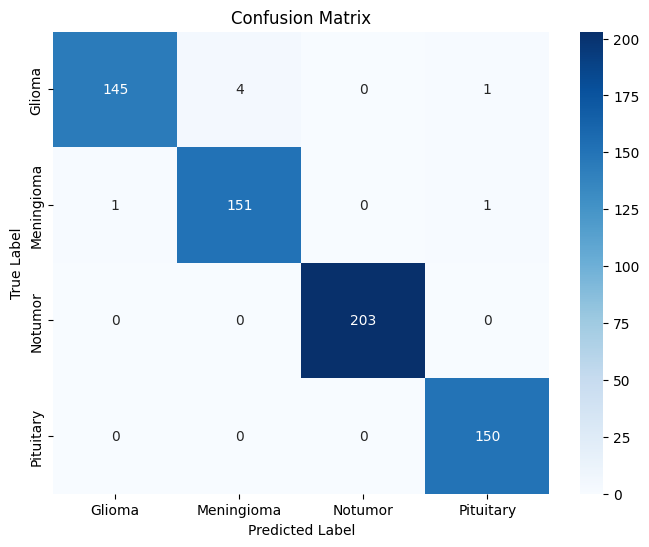

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sb
class_names=['Glioma','Meningioma','Notumor','Pituitary']

ytrue = np.argmax(ytest, axis=1)

cm = confusion_matrix(ytrue, ypred)
plt.figure(figsize=(8, 6))
sb.heatmap(cm, cmap='Blues', annot=True, fmt='d',
           xticklabels=class_names,
           yticklabels=class_names)

plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.savefig('CONFUSION_MATRIX_LABELED(25).png', dpi=300, bbox_inches='tight')
plt.show()


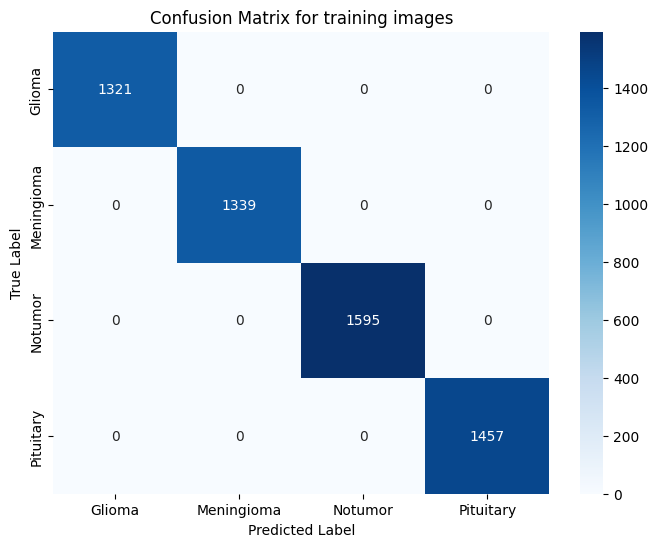

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sb
class_names=['Glioma','Meningioma','Notumor','Pituitary']

ytrue = np.argmax(ytrain, axis=1)

cm = confusion_matrix(ytrue, ypred_train)
plt.figure(figsize=(8, 6))
sb.heatmap(cm, cmap='Blues', annot=True, fmt='d',
           xticklabels=class_names,
           yticklabels=class_names)

plt.title('Confusion Matrix for training images')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.savefig('CONFUSION_MATRIX_LABELED(25_train).png', dpi=300, bbox_inches='tight')
plt.show()

              precision    recall  f1-score   support

      Glioma     0.9932    0.9667    0.9797       150
  Meningioma     0.9742    0.9869    0.9805       153
     Notumor     1.0000    1.0000    1.0000       203
   Pituitary     0.9868    1.0000    0.9934       150

    accuracy                         0.9893       656
   macro avg     0.9885    0.9884    0.9884       656
weighted avg     0.9894    0.9893    0.9893       656



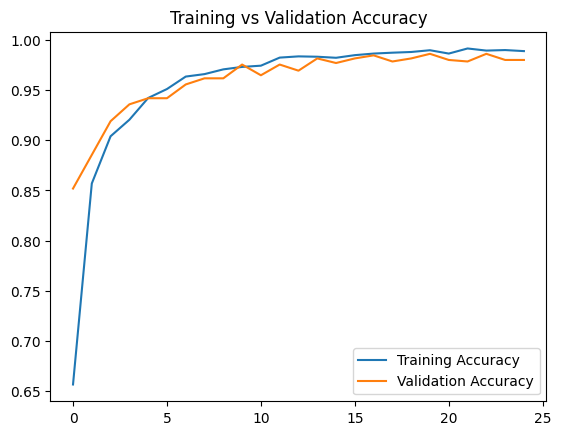

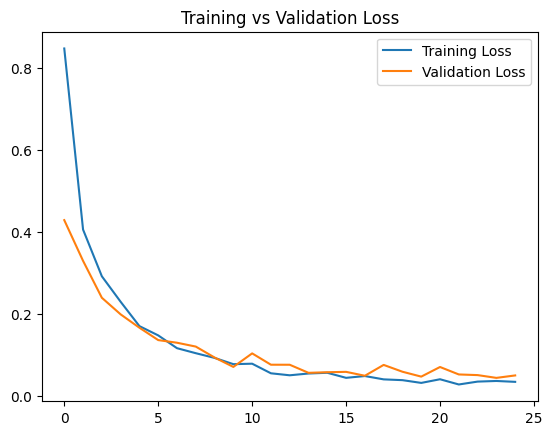

In [20]:
from sklearn.metrics import classification_report,accuracy_score
ytrue_test = np.argmax(ytest, axis=1)
print(classification_report(ytrue_test,ypred,target_names=class_names,digits=4))
acc = x.history['accuracy']
loss = x.history['loss']
val_acc = x.history['val_accuracy']
val_loss = x.history['val_loss']


plt.figure()
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.savefig('accuracy_vs_validation(25).png', dpi=300) 


plt.figure()
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.legend()
plt.savefig('loss_vs_validation(25).png', dpi=300) 

plt.show()


In [21]:

model.save("25_epochs_weights_new_inception.h5")


In [22]:
import time
import pandas as pd
print("\n--- Model Inference Time Statistics ---")

inference_times_ms = []

for i in range(X_test.shape[0]):
    img = xtest[i]
    img_batch = np.expand_dims(img, axis=0)

    start_time = time.time()
    _ = model.predict(img_batch, verbose=0)
    end_time = time.time()

    duration_ms = (end_time - start_time) * 1000
    inference_times_ms.append(duration_ms)

min_time_ms = np.min(inference_times_ms)
max_time_ms = np.max(inference_times_ms)
avg_time_ms = np.mean(inference_times_ms)

inference_results = pd.DataFrame({
    'Model': ['Inception'],
    'Min. Time (ms)': [f"{min_time_ms:.1f}"],
    'Max. Time (ms)': [f"{max_time_ms:.1f}"],
    'Avg. Time (ms)': [f"{avg_time_ms:.1f}"]
})

print(inference_results.to_string(index=False))
inference_results.to_csv('Inception.csv', index=False)
print("\nModel inference time table saved as 'Model_Inference_Time.csv'")


--- Model Inference Time Statistics ---
    Model Min. Time (ms) Max. Time (ms) Avg. Time (ms)
Inception          147.4          674.1          280.3

Model inference time table saved as 'Model_Inference_Time.csv'
